# Setup

In [1]:
import pandas as pd
import torch
from src.template_generation import *
from src.uid import *
from src.unigram import UnigramLM
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import permutations
import nltk
nltk.download("names")
from nltk.corpus import names

c:\Users\tianq\Desktop\active-passive-alternations\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\tianq\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
2026-08-21 13:37:35 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES
2026-08-21 13:37:35 INFO: Downloaded file to C:\Users\tianq\stanza_resources\resources.json
2026-08-21 13:37:36 INFO: Loading these models for language: en (English):
| Processor | Package           |
---------------------------------
| tokenize  | combined          |
| mwt       | combined          |
| pos       | combined_charlm   |
| lemma     |

In [2]:
# Load model
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")  # metal for mac
else:
    device = torch.device("cpu")
print(f"Loading model on {device}...", end="")
tokenizer, model, _ = load_lm(model_name='distilgpt2', device=device)

Loading model on cuda...

Loading weights: 100%|██████████| 76/76 [00:00<00:00, 1842.71it/s, Materializing param=transformer.wte.weight]            
GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


# Experiments

## Load Templates

In [3]:
with open("./data/templates/active_templates.txt", "r") as f:
    active_templates = f.readlines()
with open("./data/templates/passive_templates.txt", "r") as f:
    passive_templates = f.readlines()

templates = pd.DataFrame({
    "sent_id": range(len(passive_templates)),
    "passive_template": [temp.strip() for temp in passive_templates],
    "active_template": [temp.strip() for temp in active_templates]
})

In [4]:
templates.head()

,sent_id,passive_template,active_template
0,0,"During the intermission, <PRE> and <CTL> were ...","During the intermission, <PRE> and <CTL> were ..."
1,1,"On a crisp autumn morning, <PRE> and <CTL> wer...","On a crisp autumn morning, <PRE> and <CTL> wer..."
2,2,"At the end of a long semester, <PRE> and <CTL>...","At the end of a long semester, <PRE> and <CTL>..."
3,3,<PRE> and <CTL> were rehearsing in the small s...,<PRE> and <CTL> were rehearsing in the small s...
4,4,"During the charity gala last spring, <PRE> and...","During the charity gala last spring, <PRE> and..."


## Generate Data

In [5]:
variants = []
names_list = names.words("female.txt") + names.words("male.txt")
np.random.seed(3)
names_sample = np.random.choice(names_list, size=4)
print(names_sample)
for idx, row in templates.iterrows():
    for perm in permutations(names_sample):
        for template in [row['passive_template'], row['active_template']]:
            result = generate_variants(template, *perm, template==row['passive_template'])
            result['sent_id'] = row['sent_id']
            variants.append(result)
    
variants = pd.concat(variants, ignore_index=True)
for sent in np.random.choice(variants['text'], 10):
    print(sent)

['Gilles' 'Eugine' 'Marie' 'Estell']
During the extended lunch break on the second day of the intensive professional development course held at the downtown hotel conference suite, Eugine and Estell were grabbing a quick sandwich in the busy atrium cafe on the ground floor. Marie spontaneously invited Eugine to join a small informal working group that was planning to continue the morning's most stimulating discussion over the coming weeks.
On a golden Saturday afternoon in early October, Estell and Marie were raking leaves in the sprawling back garden of the old Victorian house on the corner. Eugine cheerfully roped Estell into a spontaneous leaf pile jumping contest that quickly drew the attention of several amused neighbors.
On a cold and clear January morning at the outdoor ice rink set up in the central plaza for the winter festival, Gilles and Estell were lacing up their skates on the bench at the edge of the rink. Eugine patiently steadied Marie by the arm as they tentatively ste

In [132]:
[tokenizer(name) for name in names_sample]

[{'input_ids': [38, 21718], 'attention_mask': [1, 1]},
 {'input_ids': [36, 1018, 500], 'attention_mask': [1, 1, 1]},
 {'input_ids': [44507], 'attention_mask': [1]},
 {'input_ids': [22362, 695], 'attention_mask': [1, 1]}]

In [26]:
variants.head()

,patient,agent,control,passive,subject,object,given,text,sent_id
0,Eugine,Gilles,"(Marie, Estell)",True,Eugine,Gilles,Gilles,"During the intermission, Gilles and Estell wer...",0
1,Eugine,Gilles,"(Marie, Estell)",True,Eugine,Gilles,Eugine,"During the intermission, Eugine and Estell wer...",0
2,Eugine,Gilles,"(Marie, Estell)",True,Eugine,Gilles,Marie,"During the intermission, Marie and Estell were...",0
3,Eugine,Gilles,"(Marie, Estell)",False,Gilles,Eugine,Gilles,"During the intermission, Gilles and Estell wer...",0
4,Eugine,Gilles,"(Marie, Estell)",False,Gilles,Eugine,Eugine,"During the intermission, Eugine and Estell wer...",0


In [7]:
variants.iloc[0]

patient                                               Eugine
agent                                                 Gilles
control                                      (Marie, Estell)
passive                                                 True
subject                                               Eugine
object                                                Gilles
given                                                 Gilles
text       During the intermission, Gilles and Estell wer...
sent_id                                                    0
Name: 0, dtype: object

## Compute Surprisals

In [ ]:
uid_results = []
unigram = UnigramLM(tokenizer)
unigram.fit(" ".join(variants['text']), uid_unit="word")
for i in tqdm(range(variants.shape[0])):
    try:
        variant = variants.iloc[i]
        text = variant['text']
        preamble, sentence = text.split(". ")
        preamble += "."
        for context in [preamble, ""]:
            tokens, surprisals = compute_surprisal(sentence, 
                            context, 
                            sentences=[context, sentence], 
                            sent_idx=1, 
                            tokenizer=tokenizer, 
                            model=model,
                            device=device)
            surprisals, units = process_surprisals(tokenizer,
                                                tokens,
                                                surprisals,
                                                uid_unit="word")
            uni_probs, _ = unigram(tokens)
            result = get_uid_metrics(surprisals, uni_probs)
            result['units'] = units
            result['context'] = context
            result['sentence'] = sentence
            result.update(dict(variant))
            uid_results.append(result)
        if i % 100 == 0:
            # print(f"Processed {i} sentences")
            pd.DataFrame(uid_results).to_csv("temp_results.csv", index=False)
    except Exception as e:
        print(f"Error processing sentence: {text}")
        print(f"Error details: {e}")
        continue
uid_results = pd.DataFrame(uid_results)
uid_results.to_csv("uid_results.csv", index=False)
uid_results.head(3)

100%|██████████| 13824/13824 [1:08:21<00:00,  3.37it/s]


,raw_surps,surp_mean,surp_slor,uid_std,uid_mad,uid_pwd,uid_range,uid_cv,uid_slope,uid_len,...,sentence,patient,agent,control,passive,subject,object,given,text,sent_id
0,"[42.62702226638794, 3.7734079360961914, 13.702...",9.856373,-1.803712,12.943612,9.154122,248.895923,41.058121,1.313223,-3.445082,8,...,Eugine was tapped on the shoulder by Gilles.,Eugine,Gilles,"(Marie, Estell)",True,Eugine,Gilles,Gilles,"During the intermission, Gilles and Estell wer...",0
1,"[30.909637928009033, 5.983169078826904, 11.956...",11.558665,-3.506003,9.584958,7.617560,187.222940,29.331104,0.829244,-1.038869,8,...,Eugine was tapped on the shoulder by Gilles.,Eugine,Gilles,"(Marie, Estell)",True,Eugine,Gilles,Gilles,"During the intermission, Gilles and Estell wer...",0
2,"[20.56373479962349, 3.594978094100952, 14.1363...",8.192598,-0.139937,7.324729,6.864670,108.227695,19.145105,0.894067,-0.846157,8,...,Eugine was tapped on the shoulder by Gilles.,Eugine,Gilles,"(Marie, Estell)",True,Eugine,Gilles,Eugine,"During the intermission, Eugine and Estell wer...",0


In [ ]:
# uid_results = pd.DataFrame(uid_results)
uid_results.shape, uid_results.columns

((46, 26),
 Index(['raw_surps', 'surp_mean', 'surp_slor', 'uid_std', 'uid_mad', 'uid_pwd',
        'uid_range', 'uid_cv', 'uid_slope', 'uid_len', 'units', 'context',
        'sentence', 'patient', 'agent', 'control', 'passive', 'subject',
        'object', 'given', 'text', 'sent_id', 'given_first', 'given_last',
        'given_pos', 'context_type'],
       dtype='str'))

# Analysis

List of questions to answer:
1. Are given-first orderings more or less uniform?
    - Test pairwise differences against given-first vs. given-last, between passive vs. active
2. Are surprisals at the given constituent lower or higher than the non-given?
3. Does including discourse context (preamble) enhance the difference?

** Check that Surp STD contains the first word 

## Data Cleaning

In [122]:
uid_results = pd.read_csv("uid_results.csv")

In [123]:
uid_results["given_first"] = uid_results["given"] == uid_results["subject"]
uid_results["given_last"] = uid_results["given"] == uid_results["object"]
uid_results["given_pos"] = ["f" if uid_results["given_first"].iloc[i] 
                                else "l" if uid_results['given_last'].iloc[i] 
                                else "c"
                              for i in range(uid_results.shape[0])]
uid_results["has_context"] = uid_results["context"].notna()
uid_results["control"] = uid_results["control"].apply(lambda x: eval(x) if isinstance(x, str) else x)
uid_results["control1"] = uid_results["control"].str[0]
uid_results["control2"] = uid_results["control"].str[1]
uid_results.head(3)

,raw_surps,surp_mean,surp_slor,uid_std,uid_mad,uid_pwd,uid_range,uid_cv,uid_slope,uid_len,...,object,given,text,sent_id,given_first,given_last,given_pos,has_context,control1,control2
0,"[42.62702226638794, 3.7734079360961914, 13.702...",9.856373,-1.803712,12.943612,9.154122,248.895923,41.058121,1.313223,-3.445082,8,...,Gilles,Gilles,"During the intermission, Gilles and Estell wer...",0,False,True,l,True,Marie,Estell
1,"[30.909637928009033, 5.983169078826904, 11.956...",11.558665,-3.506003,9.584958,7.617560,187.222940,29.331104,0.829244,-1.038869,8,...,Gilles,Gilles,"During the intermission, Gilles and Estell wer...",0,False,True,l,False,Marie,Estell
2,"[20.56373479962349, 3.594978094100952, 14.1363...",8.192598,-0.139937,7.324729,6.864670,108.227695,19.145105,0.894067,-0.846157,8,...,Gilles,Eugine,"During the intermission, Eugine and Estell wer...",0,True,False,f,True,Marie,Estell


In [112]:
uid_results.iloc[2]['sentence']

'Eugine was tapped on the shoulder by Gilles.'

## Q1: GF vs. GL vs. Ctl

Overall Distributions

In [113]:
uid_results.groupby(['passive', 'given_pos'])[["surp_slor", "uid_std", "uid_pwd"]].mean()

surp_slor   uid_std    uid_pwd
passive given_pos                                
False   c          -0.783261  7.366722  65.803203
        f          -0.340105  6.371301  58.520852
        l          -0.424681  7.187821  58.685886
True    c          -0.459404  6.885576  89.573529
        f          -0.085456  6.053327  76.455695
        l          -0.131940  6.674005  80.965935

Text(0.5, 0.98, 'UID Metric Distributions')

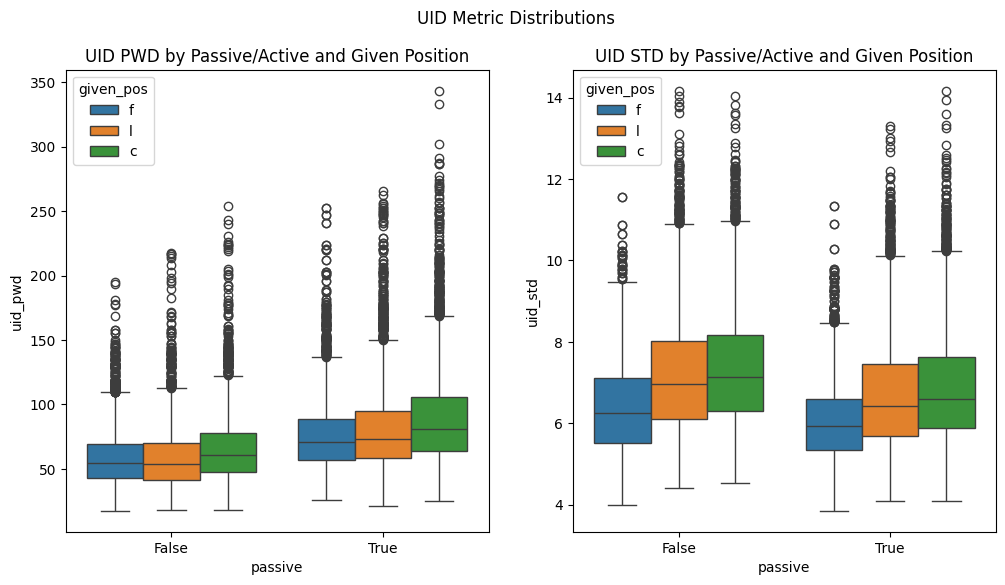

In [114]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
sns.boxplot(data=uid_results, x='passive', y='uid_pwd', hue='given_pos', ax=axs[0])
axs[0].set_title("UID PWD by Passive/Active and Given Position")
sns.boxplot(data=uid_results, x='passive', y='uid_std', hue='given_pos', ax=axs[1])
axs[1].set_title("UID STD by Passive/Active and Given Position")
fig.suptitle("UID Metric Distributions")

Pairwise Differences

Sentence pairs should have the same subject, object, given names, and given position. This will be passive - active.

In [115]:
uid_results.columns

Index(['raw_surps', 'surp_mean', 'surp_slor', 'uid_std', 'uid_mad', 'uid_pwd',
       'uid_range', 'uid_cv', 'uid_slope', 'uid_len', 'units', 'context',
       'sentence', 'patient', 'agent', 'control', 'passive', 'subject',
       'object', 'given', 'text', 'sent_id', 'given_first', 'given_last',
       'given_pos', 'has_context', 'control1', 'control2'],
      dtype='str')

In [172]:
get_diff = lambda s: s.diff().iloc[1]
mapping = {
    "uid_std": get_diff,
    "uid_pwd": get_diff,
    "text": lambda s: list(s),
    "sentence": lambda s: list(s),
    "context": lambda s: list(s),
    "units": lambda s: list(s),
    "given_pos": lambda s: " to ".join(s)
}
uid_results_diff = (uid_results[(uid_results['given_pos'] != 'c') & (uid_results['has_context'])]
                    .groupby(
                        ["sent_id", "control2", "control1", "given", "patient", "agent"]
                    )[["uid_std", "uid_pwd", "text", "given_pos", "sentence", "context", "units"]]
                    .agg(mapping).reset_index())
uid_results_diff = uid_results_diff[uid_results_diff['given_pos'].isin(["f to l", "l to f"])]
uid_results_diff.head(10) # active - passive


,sent_id,control2,control1,given,patient,agent,uid_std,uid_pwd,text,sentence,context,units,given_pos
0,0,Estell,Eugine,Gilles,Gilles,Marie,-0.656845,-86.168436,"[During the intermission, Gilles and Estell we...","[Gilles was tapped on the shoulder by Marie., ...","[During the intermission, Gilles and Estell we...","[['Gilles', 'Ġwas', 'Ġtapped', 'Ġon', 'Ġthe', ...",f to l
1,0,Estell,Eugine,Gilles,Marie,Gilles,-0.264810,-32.432271,"[During the intermission, Gilles and Estell we...","[Marie was tapped on the shoulder by Gilles., ...","[During the intermission, Gilles and Estell we...","[['Marie', 'Ġwas', 'Ġtapped', 'Ġon', 'Ġthe', '...",l to f
2,0,Estell,Eugine,Marie,Gilles,Marie,-2.340849,-74.990806,"[During the intermission, Marie and Estell wer...","[Gilles was tapped on the shoulder by Marie., ...","[During the intermission, Marie and Estell wer...","[['Gilles', 'Ġwas', 'Ġtapped', 'Ġon', 'Ġthe', ...",l to f
3,0,Estell,Eugine,Marie,Marie,Gilles,1.624298,-36.992692,"[During the intermission, Marie and Estell wer...","[Marie was tapped on the shoulder by Gilles., ...","[During the intermission, Marie and Estell wer...","[['Marie', 'Ġwas', 'Ġtapped', 'Ġon', 'Ġthe', '...",f to l
4,0,Estell,Gilles,Eugine,Eugine,Marie,-0.924951,-87.455654,"[During the intermission, Eugine and Estell we...","[Eugine was tapped on the shoulder by Marie., ...","[During the intermission, Eugine and Estell we...","[['Eugine', 'Ġwas', 'Ġtapped', 'Ġon', 'Ġthe', ...",f to l
5,0,Estell,Gilles,Eugine,Marie,Eugine,-0.103238,-40.496579,"[During the intermission, Eugine and Estell we...","[Marie was tapped on the shoulder by Eugine., ...","[During the intermission, Eugine and Estell we...","[['Marie', 'Ġwas', 'Ġtapped', 'Ġon', 'Ġthe', '...",l to f
6,0,Estell,Gilles,Marie,Eugine,Marie,-5.472287,-158.663079,"[During the intermission, Marie and Estell wer...","[Eugine was tapped on the shoulder by Marie., ...","[During the intermission, Marie and Estell wer...","[['Eugine', 'Ġwas', 'Ġtapped', 'Ġon', 'Ġthe', ...",l to f
7,0,Estell,Gilles,Marie,Marie,Eugine,5.681544,54.278867,"[During the intermission, Marie and Estell wer...","[Marie was tapped on the shoulder by Eugine., ...","[During the intermission, Marie and Estell wer...","[['Marie', 'Ġwas', 'Ġtapped', 'Ġon', 'Ġthe', '...",f to l
8,0,Estell,Marie,Eugine,Eugine,Gilles,0.594343,-55.464272,"[During the intermission, Eugine and Estell we...","[Eugine was tapped on the shoulder by Gilles.,...","[During the intermission, Eugine and Estell we...","[['Eugine', 'Ġwas', 'Ġtapped', 'Ġon', 'Ġthe', ...",f to l
9,0,Estell,Marie,Eugine,Gilles,Eugine,-1.331207,-63.655939,"[During the intermission, Eugine and Estell we...","[Gilles was tapped on the shoulder by Eugine.,...","[During the intermission, Eugine and Estell we...","[['Gilles', 'Ġwas', 'Ġtapped', 'Ġon', 'Ġthe', ...",l to f


In [173]:
uid_results_diff['text'].iloc[500]

['On the first day of the retreat, Estell and Eugine were checking in at the rustic mountain lodge. Estell was warmly offered a seat by the fireplace by Gilles.',
 'On the first day of the retreat, Estell and Eugine were checking in at the rustic mountain lodge. Gilles warmly offered Estell a seat by the fireplace.']

In [174]:
uid_results_diff['given_pos'].value_counts()

given_pos
f to l    2280
l to f    2280
Name: count, dtype: int64

Text(0.5, 1.0, 'UID PWD Active - Passive')

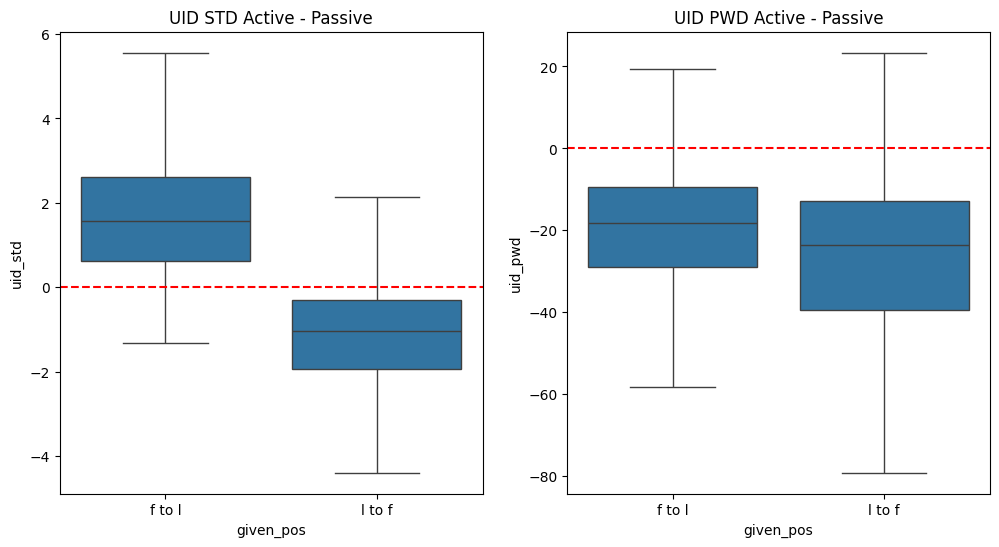

In [175]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
sns.boxplot(data=uid_results_diff, x='given_pos', y='uid_std', showfliers=False, ax=ax[0])
ax[0].axhline(y=0, color='r', linestyle='--')
ax[0].set_title("UID STD Active - Passive")
sns.boxplot(data=uid_results_diff, x='given_pos', y='uid_pwd', showfliers=False, ax=ax[1])
ax[1].axhline(y=0, color='r', linestyle='--')
ax[1].set_title("UID PWD Active - Passive")

In [118]:
sentence = variants_full.iloc[0]
surprisals = sentence['raw_surps']
units1 = [s.strip('Ġ') for s in sentence['units']]
sns.lineplot(x=range(len(surprisals)), y=surprisals, marker='o', label=sentence['given_pos'])

sentence = variants_full.iloc[1]
surprisals = sentence['raw_surps']
units2 = [s.strip('Ġ') for s in sentence['units']]
sns.lineplot(x=range(len(surprisals)), y=surprisals, marker='o', label=sentence['given_pos'])

plt.xticks(ticks=range(len(surprisals)), 
           labels=[f"{unit1}:{unit2}" if unit1 != unit2 else unit1 for unit1, unit2 in zip(units1, units2)], 
           rotation=90)

NameError: name 'variants_full' is not defined